# 🦋 Lorenz Attractor & Chaos Theory Simulation

This project simulates the classic **Lorenz Attractor**, a system of ordinary differential equations first studied by Edward Lorenz in 1963. It visually demonstrates **chaos theory** and the famous *butterfly effect*—the sensitive dependence on initial conditions.

Instead of tracking a single trajectory, this script initializes a 3D grid (cube) of multiple initial conditions and integrates them simultaneously to observe how minor variations lead to drastically different topological paths.

---

## 📐 Mathematical Formulation

The Lorenz system is defined by the following set of three non-linear differential equations:

$$\begin{aligned} \frac{dx}{dt} &= \sigma (y - x) \\ \frac{dy}{dt} &= x (\rho - z) - y \\ \frac{dz}{dt} &= xy - \beta z \end{aligned}$$

### Parameters:
- $x, y, z$: Represent the state variables of the system (convection, temperature variation, etc.).
- $\sigma$ (**Prandtl number**): Typically set to $10.0$.
- $\rho$ (**Rayleigh number**): Typically set to $28.0$ (the threshold where the system exhibits chaotic behavior).
- $\beta$ (**Geometric factor**): Typically set to $\frac{8}{3} \approx 2.667$.

---

## 🚀 Features
- **3D Grid Propagation:** Generates a spatial cube of initial points using `numpy.meshgrid`.
- **High-Precision Integration:** Utilizes `scipy.integrate.solve_ivp` with strict relative and absolute tolerances (`rtol=1e-6`, `atol=1e-9`).
- **Dark-Mode Aesthetics:** Optimized 3D plotting with custom Matplotlib dark-themed rendering.

## 🛠️ Technologies Used
- **Python**
- **NumPy**
- **SciPy**
- **Matplotlib**


import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

class LorenzAttractorSimulation:
    """
    Lorenz Kaotik Çekicisi Simülasyon Sınıfı.
    
    Matematiksel Modellenme:
        dx/dt = sigma * (y - x)
        dy/dt = x * (rho - z) - y
        dzdt = x * y - beta * z
    """
    def __init__(self, sigma: float = 10.0, rho: float = 28.0, beta: float = 8.0/3.0):
        self.sigma = sigma
        self.rho = rho
        self.beta = beta

    def _lorenz_equations(self, t: float, xyz: np.ndarray) -> list:
        """
        Lorenz sisteminin non-linear diferansiyel denklemleri:
        - sigma (Prandtl sayısı): Akışkanın viskozitesinin termal iletkenliğine oranı.
        - rho (Rayleigh sayısı): Sistemdeki ısı farkını ve kaosa geçiş eşiğini belirler.
        - beta: Sistemdeki fiziksel boyut oranını ifade eder.
        """
        x, y, z = xyz
        dxdt = self.sigma * (y - x)
        dydt = x * (self.rho - z) - y
        dzdt = x * y - self.beta * z
        return [dxdt, dydt, dzdt]

    def run_simulation(self, x_range: np.ndarray, y_range: np.ndarray, z_range: np.ndarray, t_max: float = 35.0, num_points: int = 600) -> list:
        """Belirtilen 3D grid (küp) üzerindeki tüm başlangıç noktaları için yörüngeleri hesaplar."""
        gx, gy, gz = np.meshgrid(x_range, y_range, z_range)
        initial_points = np.vstack([gx.ravel(), gy.ravel(), gz.ravel()]).T
        
        t_span = (0.0, t_max)
        t_eval = np.linspace(0.0, t_max, num_points)
        
        solutions = []
        total_points = initial_points.shape[0]
        print(f"[*] Toplam {total_points} başlangıç noktası için simülasyon hesaplanıyor...")
        
        for i, p0 in enumerate(initial_points):
            sol = solve_ivp(
                self._lorenz_equations,
                t_span,
                p0,
                t_eval=t_eval,
                rtol=1e-6,
                atol=1e-9
            )
            solutions.append(sol.y)
            
        print("[+] Hesaplama tamamlandı!")
        return solutions

    @staticmethod
    def plot_trajectories(solutions: list):
        """Hesaplanan yörüngeleri karanlık tema estetiğinde 3 boyutlu uzayda çizer."""
        fig = plt.figure(figsize=(12, 10), facecolor='black')
        ax = fig.add_subplot(projection='3d')
        ax.set_facecolor('black')
        
        for sol in solutions:
            ax.plot(sol[0], sol[1], sol[2], alpha=0.5, lw=0.7)

        ax.set_title("Lorenz Attractor - Chaos & Initial Condition Cube", color='white', fontsize=14, pad=20)
        
        ax.xaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
        ax.yaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
        ax.zaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
        
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.zaxis.label.set_color('white')
        
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    x_rng = np.linspace(-3, 3, 3)
    y_rng = np.linspace(-3, 3, 3)
    z_rng = np.linspace(20, 25, 3)
    
    sim = LorenzAttractorSimulation()
    results = sim.run_simulation(x_rng, y_rng, z_rng, t_max=35, num_points=600)
    sim.plot_trajectories(results)


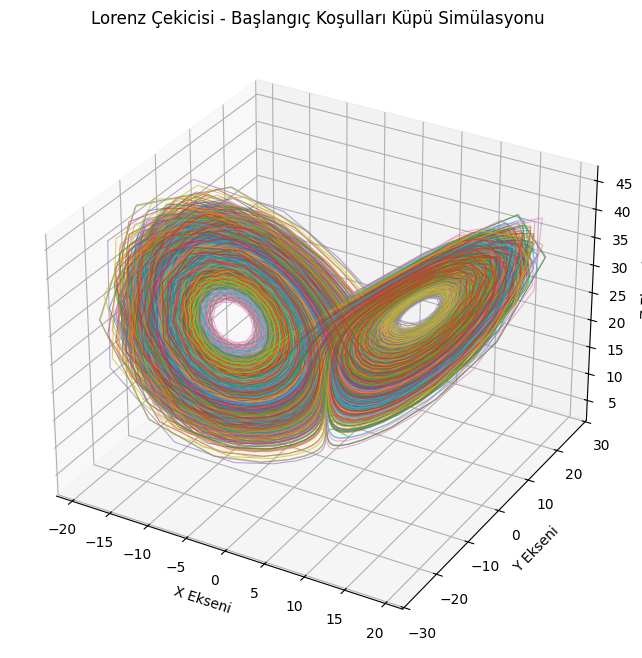

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Lorenz sisteminin diferansiyel denklemleri
def lorenz(t, xyz, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = xyz
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# 1. Başlangıç Koşulları Küpünü Oluşturma (meshgrid kullanarak)
# MATLAB'deki kod mantığına benzer şekilde 3 boyutlu bir nokta küpü tanımlıyoruz
x = np.linspace(-5, 5, 4)
y = np.linspace(-5, 5, 4)
z = np.linspace(10, 20, 4)
X0, Y0, Z0 = np.meshgrid(x, y, z)

# Noktaları (N, 3) boyutlu bir dizi haline getirelim
initial_points = np.vstack([X0.ravel(), Y0.ravel(), Z0.ravel()]).T

# Zaman aralığı
t_span = (0, 25)
t_eval = np.linspace(0, 25, 500)

# 2. Çözümleme ve Görselleştirme
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# Küpteki her bir başlangıç noktası için sistemi çözeltelim
for p0 in initial_points:
    sol = solve_ivp(lorenz, t_span, p0, t_eval=t_eval)
    ax.plot(sol.y[0], sol.y[1], sol.y[2], alpha=0.6, lw=0.8)

ax.set_title("Lorenz Çekicisi - Başlangıç Koşulları Küpü Simülasyonu")
ax.set_xlabel("X Ekseni")
ax.set_ylabel("Y Ekseni")
ax.set_zlabel("Z Ekseni")
plt.show()


[*] Toplam 27 başlangıç noktası için simülasyon hesaplanıyor...
[+] Hesaplama tamamlandı!


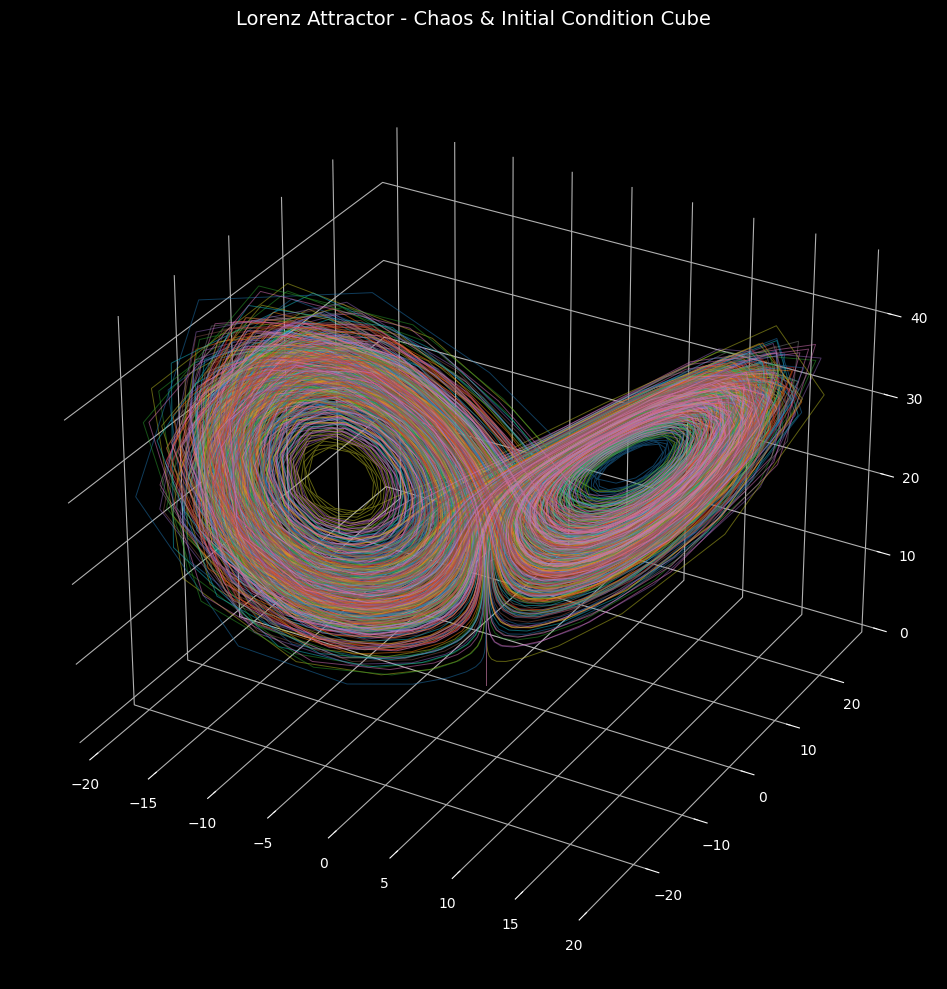

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

class LorenzAttractorSimulation:
    """
    Lorenz Kaotik Çekicisi için 3D Başlangıç Koşulları Simülasyon Sınıfı.
    Başlangıç koşullarına duyarlılığı (Kelebek Etkisi) görselleştirir.
    """
    def __init__(self, sigma: float = 10.0, rho: float = 28.0, beta: float = 8.0/3.0):
        self.sigma = sigma
        self.rho = rho
        self.beta = beta

    def _lorenz_equations(self, t: float, xyz: np.ndarray) -> list:
        """Lorenz sisteminin non-linear diferansiyel denklemleri."""
        x, y, z = xyz
        dxdt = self.sigma * (y - x)
        dydt = x * (self.rho - z) - y
        dzdt = x * y - self.beta * z
        return [dxdt, dydt, dzdt]

    def run_simulation(self, x_range: np.ndarray, y_range: np.ndarray, z_range: np.ndarray, t_max: float = 35.0, num_points: int = 600) -> list:
        """Belirtilen 3D grid (küp) üzerindeki tüm başlangıç noktaları için yörüngeleri hesaplar."""
        gx, gy, gz = np.meshgrid(x_range, y_range, z_range)
        initial_points = np.vstack([gx.ravel(), gy.ravel(), gz.ravel()]).T

        t_span = (0.0, t_max)
        t_eval = np.linspace(0.0, t_max, num_points)

        solutions = []
        total_points = initial_points.shape[0]
        print(f"[*] Toplam {total_points} başlangıç noktası için simülasyon hesaplanıyor...")

        for i, p0 in enumerate(initial_points):
            sol = solve_ivp(
                self._lorenz_equations,
                t_span,
                p0,
                t_eval=t_eval,
                rtol=1e-6,
                atol=1e-9
            )
            solutions.append(sol.y)

        print("[+] Hesaplama tamamlandı!")
        return solutions

    @staticmethod
    def plot_trajectories(solutions: list):
        """Hesaplanan yörüngeleri karanlık tema estetiğinde 3 boyutlu uzayda çizer."""
        fig = plt.figure(figsize=(12, 10), facecolor='black')
        ax = fig.add_subplot(projection='3d')
        ax.set_facecolor('black')

        for sol in solutions:
            # Z eksenine göre renk değişimi derinlik hissi katar
            ax.plot(sol[0], sol[1], sol[2], alpha=0.5, lw=0.7)

        ax.set_title("Lorenz Attractor - Chaos & Initial Condition Cube", color='white', fontsize=14, pad=20)

        # Eksen çerçevelerini ve arka planı şeffaflaştırarak profesyonel görünüm sağla
        ax.xaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
        ax.yaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
        ax.zaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))

        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.zaxis.label.set_color('white')

        plt.tight_layout()
        plt.show()

# --- Çalıştırma Bloğu ---
if __name__ == "__main__":
    # Küp aralıklarını ve yoğunluğunu ayarlayalım (örn: 3x3x3 = 27 farklı nokta)
    x_rng = np.linspace(-3, 3, 3)
    y_rng = np.linspace(-3, 3, 3)
    z_rng = np.linspace(20, 25, 3)

    sim = LorenzAttractorSimulation()
    results = sim.run_simulation(x_rng, y_rng, z_rng, t_max=35, num_points=600)
    sim.plot_trajectories(results)


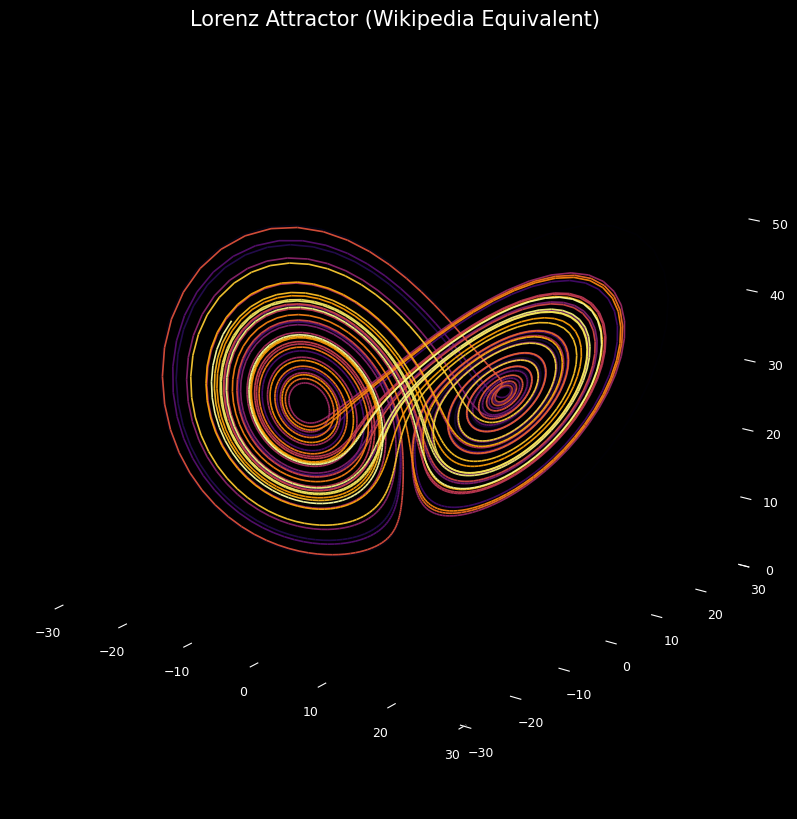

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# Lorenz attractor equations parameters
class Lorenz:
    def __init__(self, dt=0.01, sigma=10.0, rho=28.0, beta=8.0/3.0, x=1.0, y=1.0, z=1.0):
        self.dt = dt
        self.sigma = sigma
        self.rho = rho
        self.beta = beta
        self.x = x
        self.y = y
        self.z = z

    def step(self):
        dx = self.sigma * (self.y - self.x)
        dy = self.x * (self.rho - self.z) - self.y
        dz = self.x * self.y - self.beta * self.z
        self.x += self.dt * dx
        self.y += self.dt * dy
        self.z += self.dt * dz
        return self.x, self.y, self.z

# Initialize and generate smooth steps
attractor = Lorenz()
points = []

frames = 120
steps_per_frame = 50
total_steps = frames * steps_per_frame

for _ in range(total_steps):
    points.append(attractor.step())

points = np.array(points)

# Prepare segments for 3D gradient line coloring (Wikipedia quality)
points_reshaped = points.reshape(-1, 1, 3)
segments = np.concatenate([points_reshaped[:-1], points_reshaped[1:]], axis=1)
colors = np.linspace(0, 1, len(segments))

# Configure Matplotlib dark aesthetic
fig = plt.figure(figsize=(12, 10), facecolor='black')
ax = fig.add_subplot(projection='3d')
ax.set_facecolor('black')

# Create a Line3DCollection with smooth color transition
lc = Line3DCollection(segments, cmap='inferno', array=colors, linewidth=1.2, alpha=0.95)
ax.add_collection3d(lc)

# Turn off axis borders and background panes
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')
ax.tick_params(colors='white', labelsize=9)

# Match coordinate limits from Julia configuration
ax.set_xlim(-30, 30)
ax.set_ylim(-30, 30)
ax.set_zlim(0, 50)

# Apply the exact final rotation angle derived from the azimuth equation
final_azim = np.degrees(1.7 * np.pi + 0.3 * np.sin(2 * np.pi * 120 / 120))
ax.view_init(elev=20, azim=final_azim)

plt.title("Lorenz Attractor (Wikipedia Equivalent)", color='white', fontsize=15, pad=10)

# Save the production-ready high resolution graphic
plt.savefig('/content/3D_Lorenz_Chaotic_Attactor.png', facecolor=fig.get_facecolor(), edgecolor='none', dpi=200)
plt.show()

In [10]:
import numpy as np
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
import matplotlib.colors as mcolors

# Parameters
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

# Initial values
varini = [1.0, 1.0, 1.0]

# Lorenz system equations for solve_ivp
def lorenz(t, state):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Solve the system from t=0 to t=100 with a step of 0.01
t_span = (0, 100)
t_eval = np.arange(0, 100, 0.01)

sol = solve_ivp(lorenz, t_span, varini, t_eval=t_eval, rtol=1e-10)

# Trajectory data
vals_x = sol.y[0]
vals_y = sol.y[1]
vals_z = sol.y[2]
n_points = len(t_eval)

# Generate colors similar to the R 'rainbow(10)' repeating loop
rainbow_colors = [
    '#FF0000', '#FF9900', '#CCFF00', '#33FF00', '#00FF66',
    '#00FFFF', '#0066FF', '#3300FF', '#CC00FF', '#FF0099'
]
color_map = [rainbow_colors[i % 10] for i in range(n_points)]

# Generate interactive 3D Line plot with Plotly
fig = go.Figure(data=go.Scatter3d(
    x=vals_x,
    y=vals_y,
    z=vals_z,
    mode='lines',
    line=dict(
        width=4,
        color=color_map
    )
))

fig.update_layout(
    title="Interactive 3D Lorenz Attractor (Python Plotly)",
    template="plotly_dark",
    scene=dict(
        xaxis_title="X Ekseni",
        yaxis_title="Y Ekseni",
        zaxis_title="Z Ekseni"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

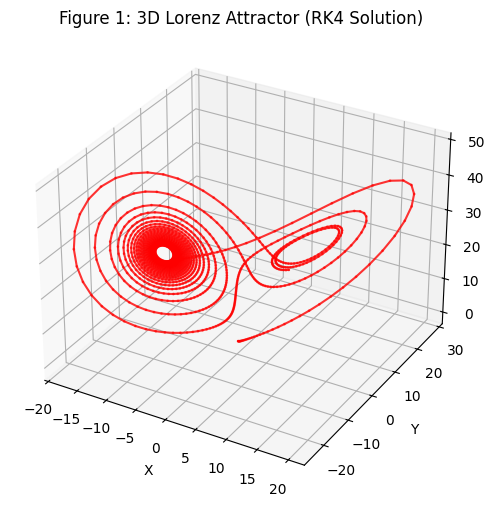

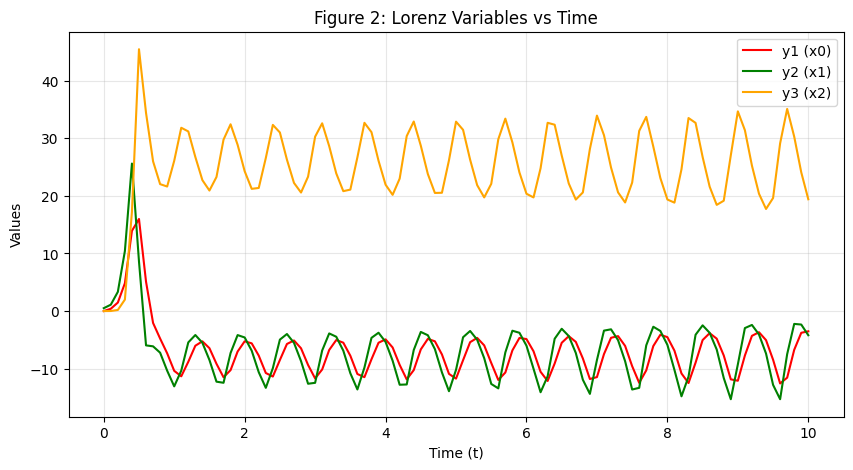

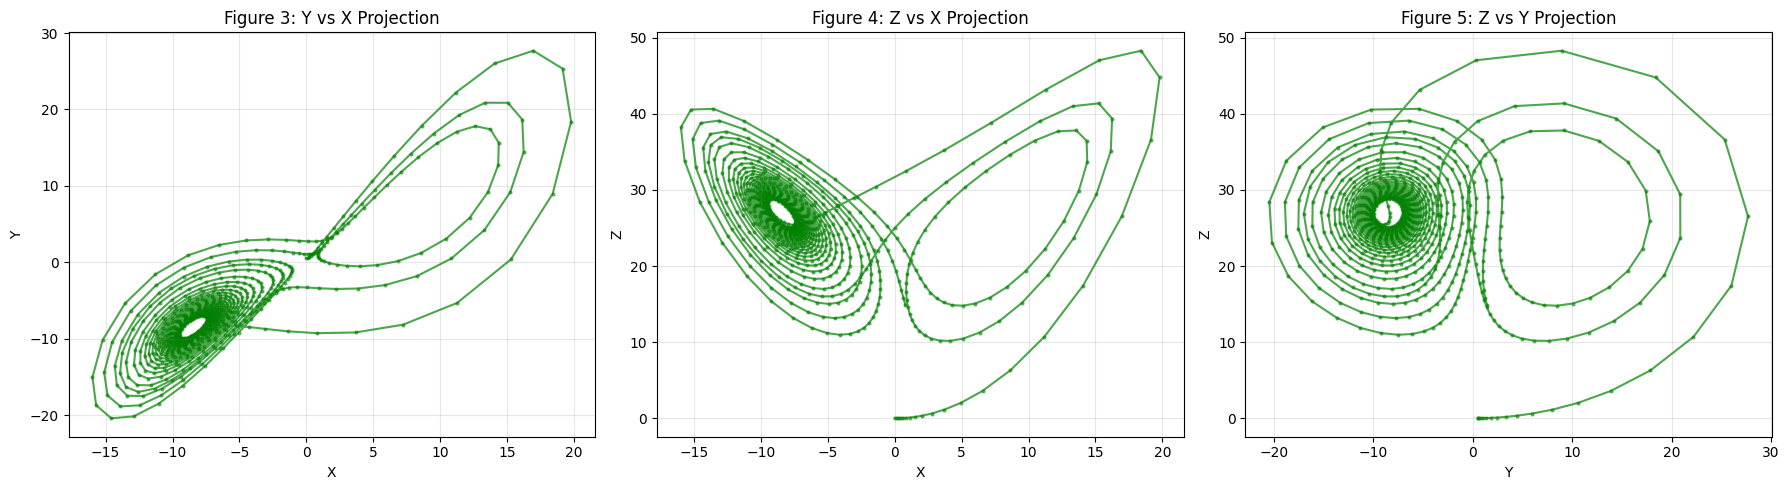

In [12]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define symbolic variables using SymPy
t = sp.Symbol('t')
x0, x1, x2 = sp.symbols('x0 x1 x2')
v = [x0, x1, x2]

def Runge_Kutta(f, v, a, b, h, n):
    tlist = [a + i * h for i in range(n + 1)]
    y = [[0.0, 0.0, 0.0] for _ in range(n + 1)]
    m = len(f)
    vm = len(v)
    if m != vm:
        return "error, number of equations is not equal with the number of variables."
    for r in range(vm):
        y[0][r] = float(b[r])

    # Pre-compile lambda functions for super fast numerical evaluation instead of slow symbolic .subs()
    f_lambdas = [sp.lambdify((t, v[0], v[1], v[2]), eq) for eq in f]

    for i in range(1, n + 1):
        t_prev = tlist[i-1]
        y_prev = y[i-1]

        # k1
        k1 = [h * f_lambdas[j](t_prev, y_prev[0], y_prev[1], y_prev[2]) for j in range(m)]

        # k2
        t_half = t_prev + h / 2.0
        k2 = [h * f_lambdas[j](t_half, y_prev[0] + k1[0]/2.0, y_prev[1] + k1[1]/2.0, y_prev[2] + k1[2]/2.0) for j in range(m)]

        # k3
        k3 = [h * f_lambdas[j](t_half, y_prev[0] + k2[0]/2.0, y_prev[1] + k2[1]/2.0, y_prev[2] + k2[2]/2.0) for j in range(m)]

        # k4
        t_next = t_prev + h
        k4 = [h * f_lambdas[j](t_next, y_prev[0] + k3[0], y_prev[1] + k3[1], y_prev[2] + k3[2]) for j in range(m)]

        # Update state
        for j in range(m):
            y[i][j] = y_prev[j] + (k1[j] + 2.0 * k2[j] + 2.0 * k3[j] + k4[j]) / 6.0

    return tlist, y

# --- (Figure 1) 3D Lorenz Attractor Trajectory ---
a = 0.0
b = [0.0, 0.50, 0.0]
f = [10*(x1-x0), x0*(28-x2)-x1, x0*x1-(8/3)*x2]
n = 1600
h = 0.0125
tlist, y = Runge_Kutta(f, v, a, b, h, n)

y_arr = np.array(y)
fig1 = plt.figure(figsize=(8, 6))
ax1 = fig1.add_subplot(projection='3d')
ax1.plot(y_arr[:, 0], y_arr[:, 1], y_arr[:, 2], color='red', label='Lorenz Trajectory', alpha=0.8)
ax1.scatter(y_arr[:, 0], y_arr[:, 1], y_arr[:, 2], color='red', s=1, alpha=0.5)
ax1.set_title("Figure 1: 3D Lorenz Attractor (RK4 Solution)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
plt.show()

# --- (Figure 2) Variables vs Time ---
n2 = 100
h2 = 0.1
tlist2, y2 = Runge_Kutta(f, v, a, b, h2, n2)
y2_arr = np.array(y2)

plt.figure(figsize=(10, 5))
plt.plot(tlist2, y2_arr[:, 0], color='red', label='y1 (x0)')
plt.plot(tlist2, y2_arr[:, 1], color='green', label='y2 (x1)')
plt.plot(tlist2, y2_arr[:, 2], color='orange', label='y3 (x2)')
plt.title("Figure 2: Lorenz Variables vs Time")
plt.xlabel("Time (t)")
plt.ylabel("Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- (Figure 3, 4, 5) 2D Projections ---
n3 = 800
h3 = 0.025
tlist3, y3 = Runge_Kutta(f, v, a, b, h3, n3)
y3_arr = np.array(y3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Y vs X (y2 ve y1)
axes[0].plot(y3_arr[:, 0], y3_arr[:, 1], color='green', alpha=0.7)
axes[0].scatter(y3_arr[:, 0], y3_arr[:, 1], color='green', s=4, alpha=0.5)
axes[0].set_title("Figure 3: Y vs X Projection")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].grid(True, alpha=0.3)

# Z vs X (y3 ve y1)
axes[1].plot(y3_arr[:, 0], y3_arr[:, 2], color='green', alpha=0.7)
axes[1].scatter(y3_arr[:, 0], y3_arr[:, 2], color='green', s=4, alpha=0.5)
axes[1].set_title("Figure 4: Z vs X Projection")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Z")
axes[1].grid(True, alpha=0.3)

# Z vs Y (y3 ve y2)
axes[2].plot(y3_arr[:, 1], y3_arr[:, 2], color='green', alpha=0.7)
axes[2].scatter(y3_arr[:, 1], y3_arr[:, 2], color='green', s=4, alpha=0.5)
axes[2].set_title("Figure 5: Z vs Y Projection")
axes[2].set_xlabel("Y")
axes[2].set_ylabel("Z")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()